In [1]:
!pip install sentence-transformers pandas numpy scikit-learn matplotlib torch

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Inference Environment Initialized. Using device: {device}")

TARGET_DIM = 64

class SemanticCompressor(nn.Module):
    def __init__(self, input_dim=384, output_dim=TARGET_DIM):
        super(SemanticCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.network(x)

Inference Environment Initialized. Using device: cuda


In [2]:
# 2. Load the pre-trained base model
print("Loading Base Multilingual Model (MiniLM)...")
base_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device=device)

# 3. Load our custom trained weights
print("Loading Custom 64D Neural Compressor...")
compressor = SemanticCompressor().to(device)
try:
    compressor.load_state_dict(torch.load('best_compressor.pth', map_location=device))
    compressor.eval()
    print("Successfully loaded 'best_compressor.pth'")
except FileNotFoundError:
    print("ERROR: 'best_compressor.pth' not found. Please ensure the trained weights are in the directory.")

def load_and_align_data(sa_path, en_path):
    df_sa = pd.read_csv(sa_path)
    df_en = pd.read_csv(en_path)
    aligned_df = pd.merge(df_sa, df_en, on='Source_id', how='inner')
    aligned_df = aligned_df.sort_values('Source_id').reset_index(drop=True)
    return aligned_df

print("Loading Test Data...")
df_test = load_and_align_data('test_sa.csv', 'test_en.csv')
test_sa_texts = df_test['Sentence_sa'].tolist()
test_en_texts = df_test['Sentence_en'].tolist()
print(f"Loaded {len(test_sa_texts)} testing pairs.")

Loading Base Multilingual Model (MiniLM)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading Custom 64D Neural Compressor...
Successfully loaded 'best_compressor.pth'
Loading Test Data...
Loaded 1000 testing pairs.


In [3]:
# 5. Run Inference
print("Extracting Base 384D Embeddings...")
with torch.no_grad():
    test_sa_base = base_model.encode(test_sa_texts, convert_to_tensor=True)
    test_en_base = base_model.encode(test_en_texts, convert_to_tensor=True)

    print("Compressing to 64D via Neural Network...")
    final_sa_embeddings = compressor(test_sa_base.to(device)).cpu().numpy()
    final_en_embeddings = compressor(test_en_base.to(device)).cpu().numpy()

# 6. Calculate Cosine Similarity Score
similarities = [cosine_similarity([final_sa_embeddings[i]], [final_en_embeddings[i]])[0][0]
                for i in range(len(final_sa_embeddings))]

average_cosine_sim = np.mean(similarities)

print("\n" + "="*40)
print("       FINAL INFERENCE METRICS")
print("="*40)
print(f"Output Dimension: {final_sa_embeddings.shape[1]}")
print(f"Average Cosine Similarity: {average_cosine_sim:.4f}")
print("="*40 + "\n")

np.save('final_test_sa_embeddings.npy', final_sa_embeddings)
np.save('final_test_en_embeddings.npy', final_en_embeddings)
print("Embeddings successfully saved to .npy files.")

Extracting Base 384D Embeddings...
Compressing to 64D via Neural Network...

       FINAL INFERENCE METRICS
Output Dimension: 64
Average Cosine Similarity: 0.7814

Embeddings successfully saved to .npy files.


Generating t-SNE Visualization of the 64D latent space...


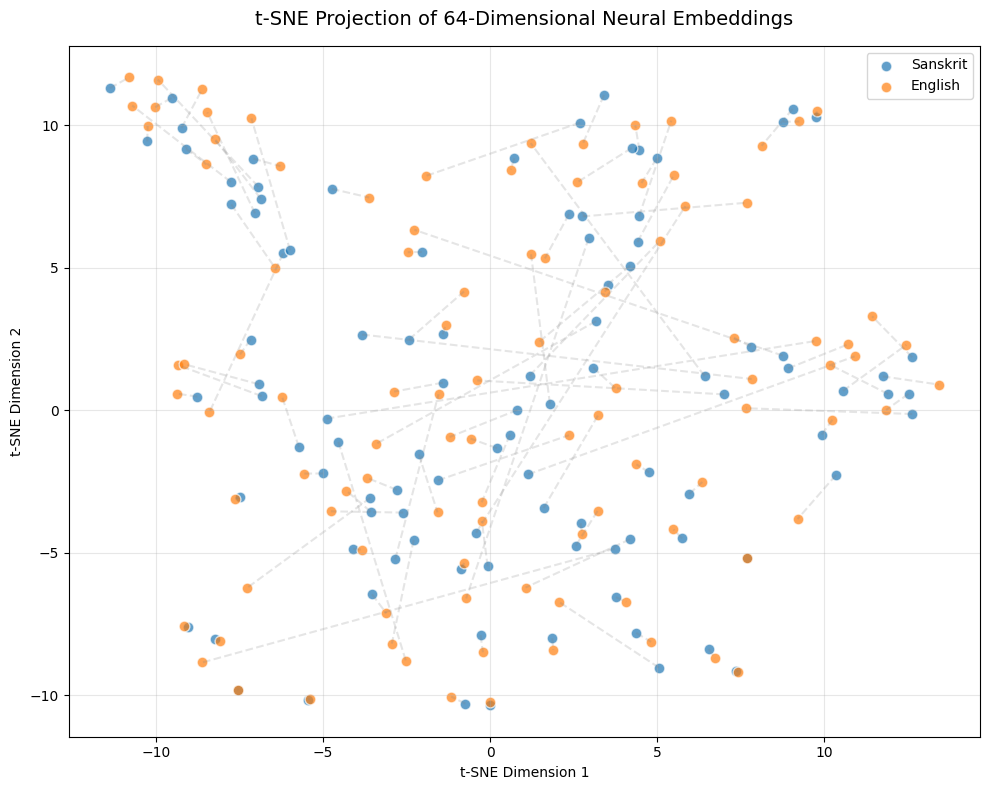

Visualization saved as 'tsne_evaluation_plot.png'


In [4]:
print("Generating t-SNE Visualization of the 64D latent space...")

sample_size = min(100, len(final_sa_embeddings))
sa_sample = final_sa_embeddings[:sample_size]
en_sample = final_en_embeddings[:sample_size]

viz_data = np.vstack((sa_sample, en_sample))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(viz_data)

sa_tsne = tsne_results[:sample_size]
en_tsne = tsne_results[sample_size:]

plt.figure(figsize=(10, 8))
plt.scatter(sa_tsne[:, 0], sa_tsne[:, 1], c='#1f77b4', label='Sanskrit', alpha=0.7, edgecolors='w', s=60)
plt.scatter(en_tsne[:, 0], en_tsne[:, 1], c='#ff7f0e', label='English', alpha=0.7, edgecolors='w', s=60)

for i in range(sample_size):
    plt.plot([sa_tsne[i, 0], en_tsne[i, 0]], [sa_tsne[i, 1], en_tsne[i, 1]], 'gray', alpha=0.2, linestyle='--')

plt.title('t-SNE Projection of 64-Dimensional Neural Embeddings', fontsize=14, pad=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('tsne_evaluation_plot.png', dpi=300)
plt.show()
print("Visualization saved as 'tsne_evaluation_plot.png'")